In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import lsst.daf.butler as dafButler
import numpy as np
import lsst.afw.display


In [2]:
butler = dafButler.Butler('dp2_prep',collections=['skymaps','u/elhoward/DM-54432/template_coadd-QC/DP2/full_wide'])

In [3]:
skymap = butler.get("skyMap", skymap="lsst_cells_v2") 

In [4]:
df_99 = pd.read_csv('/sdf/group/rubin/user/elhoward/curation/DM-54432/stats/release_cutoff_99_wide_stat_records.csv')

In [5]:
len(df_99)

1843

In [6]:
df_99

,tract,percent_coverage,u_num_accepted,u_num_rejected,u_percent_accepted,g_num_accepted,g_num_rejected,g_percent_accepted,r_num_accepted,r_num_rejected,r_percent_accepted,i_num_accepted,i_num_rejected,i_percent_accepted,z_num_accepted,z_num_rejected,z_percent_accepted,y_num_accepted,y_num_rejected,y_percent_accepted
0,8212,0.000000,0,0,NaN,0,2,0.0,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN
1,8213,0.000000,0,0,NaN,0,22,0.0,0,0,NaN,0,0,NaN,0,0,NaN,0,0,NaN
2,8214,0.000000,0,0,NaN,0,4,0.0,0,0,NaN,0,0,NaN,0,0,NaN,0,4,0.000000
3,8216,0.000000,0,13,0.000000,0,0,NaN,0,15,0.000000,0,20,0.000000,0,0,NaN,0,0,NaN
4,8217,0.000000,0,38,0.000000,0,0,NaN,0,92,0.000000,0,49,0.000000,0,0,NaN,0,3,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1838,8180,5.166667,5,87,5.434783,0,80,0.0,15,65,18.750000,8,75,9.638554,3,22,12.000000,0,11,0.000000
1839,8181,7.500000,9,69,11.538462,0,66,0.0,17,48,26.153846,8,56,12.500000,10,18,35.714286,1,27,3.571429
1840,8182,0.000000,0,10,0.000000,0,9,0.0,0,10,0.000000,0,9,0.000000,0,4,0.000000,0,4,0.000000
1841,8183,0.000000,0,0,NaN,0,16,0.0,0,7,0.000000,0,7,0.000000,0,7,0.000000,0,7,0.000000


In [7]:
def add_radec(df, skymap):
    df['ra'] = df['tract'].apply(lambda x: skymap[x].getCtrCoord().getRa().asDegrees())
    df['dec'] = df['tract'].apply(lambda x: skymap[x].getCtrCoord().getDec().asDegrees())

In [8]:
add_radec(df_99, skymap)

In [9]:
df_99

,tract,percent_coverage,u_num_accepted,u_num_rejected,u_percent_accepted,g_num_accepted,g_num_rejected,g_percent_accepted,r_num_accepted,r_num_rejected,...,i_num_rejected,i_percent_accepted,z_num_accepted,z_num_rejected,z_percent_accepted,y_num_accepted,y_num_rejected,y_percent_accepted,ra,dec
0,8212,0.000000,0,0,NaN,0,2,0.0,0,0,...,0,NaN,0,0,NaN,0,0,NaN,289.5,-8.181818
1,8213,0.000000,0,0,NaN,0,22,0.0,0,0,...,0,NaN,0,0,NaN,0,0,NaN,291.0,-8.181818
2,8214,0.000000,0,0,NaN,0,4,0.0,0,0,...,0,NaN,0,0,NaN,0,4,0.000000,292.5,-8.181818
3,8216,0.000000,0,13,0.000000,0,0,NaN,0,15,...,20,0.000000,0,0,NaN,0,0,NaN,295.5,-8.181818
4,8217,0.000000,0,38,0.000000,0,0,NaN,0,92,...,49,0.000000,0,0,NaN,0,3,0.000000,297.0,-8.181818
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1838,8180,5.166667,5,87,5.434783,0,80,0.0,15,65,...,75,9.638554,3,22,12.000000,0,11,0.000000,241.5,-8.181818
1839,8181,7.500000,9,69,11.538462,0,66,0.0,17,48,...,56,12.500000,10,18,35.714286,1,27,3.571429,243.0,-8.181818
1840,8182,0.000000,0,10,0.000000,0,9,0.0,0,10,...,9,0.000000,0,4,0.000000,0,4,0.000000,244.5,-8.181818
1841,8183,0.000000,0,0,NaN,0,16,0.0,0,7,...,7,0.000000,0,7,0.000000,0,7,0.000000,246.0,-8.181818


u 0
g 7
r 35
i 40
z 32
y 8


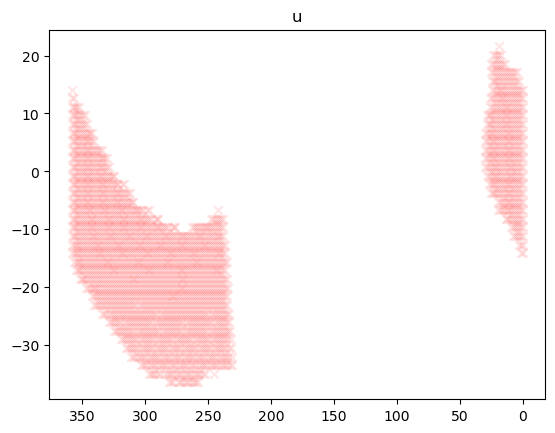

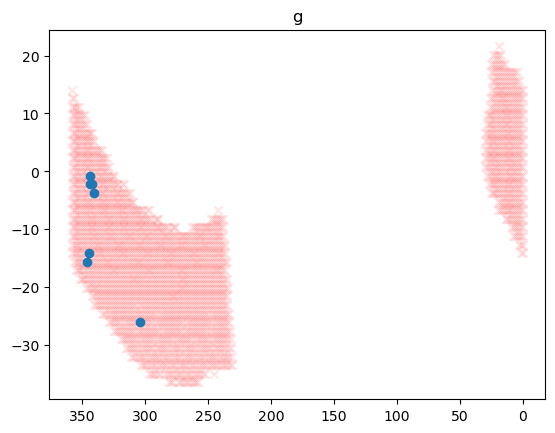

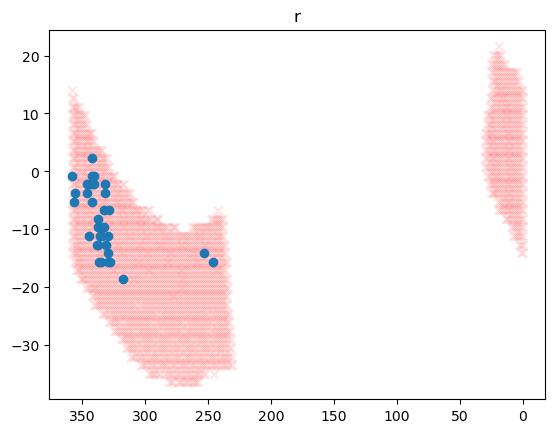

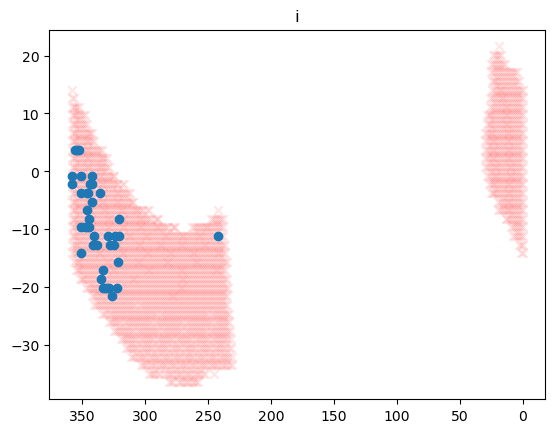

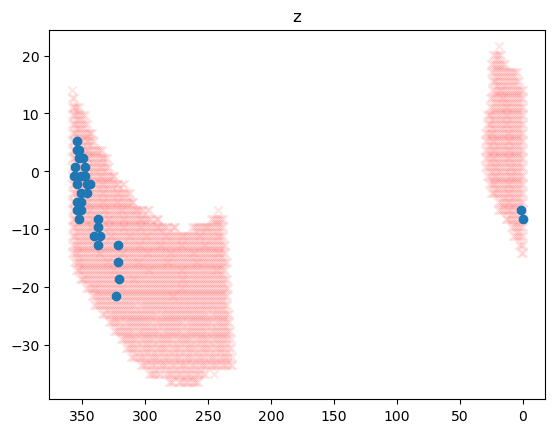

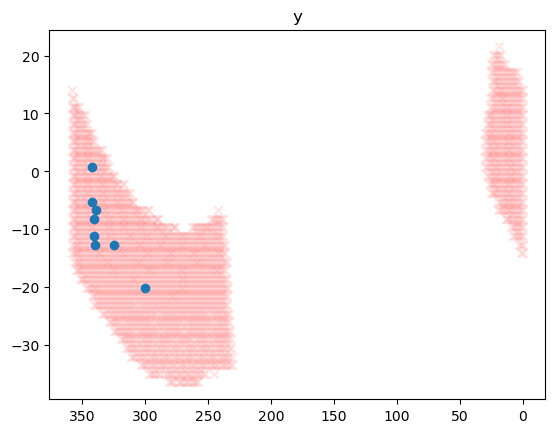

In [10]:
for band in ['u','g','r','i','z','y']:
    plt.figure()
    w = df_99[f'{band}_num_accepted'] == 100
    print(band, np.sum(w))
    plt.scatter(df_99.loc[~w,'ra'], df_99.loc[~w, 'dec'],marker='x',color='red',alpha=0.1)
    plt.scatter(df_99.loc[w,'ra'], df_99.loc[w, 'dec'])

    plt.title(band)
    plt.gca().invert_xaxis()

let's go back to the inputs for a minute

In [11]:
refs = butler.query_datasets('template_coadd_n_image', where="band = 'i' AND tract = 2393 AND skymap='lsst_cells_v2'")
len(refs)

100

In [12]:
ref = refs[0]
ref.dataId

{band: 'i', skymap: 'lsst_cells_v2', tract: 2393, patch: 0}

In [13]:
n_image = butler.get(ref)
narr = n_image.getArray()

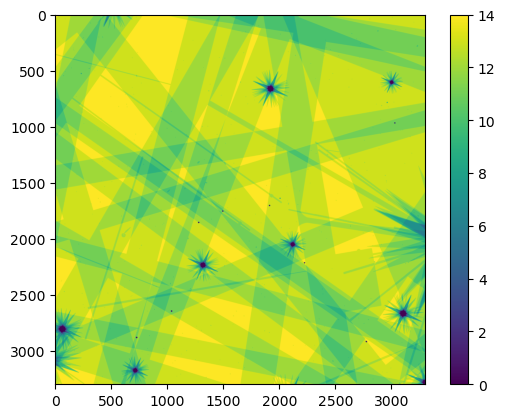

In [14]:
plt.figure()
plt.imshow(narr)
plt.colorbar()

(array([0.00126933, 0.00146244, 0.00203205, 0.00265372, 0.00390156,
        0.01032984, 0.02571754, 0.26713691, 0.5416888 , 1.        ]),
 array([ 0. ,  1.4,  2.8,  4.2,  5.6,  7. ,  8.4,  9.8, 11.2, 12.6, 14. ]),
 <BarContainer object of 10 artists>)

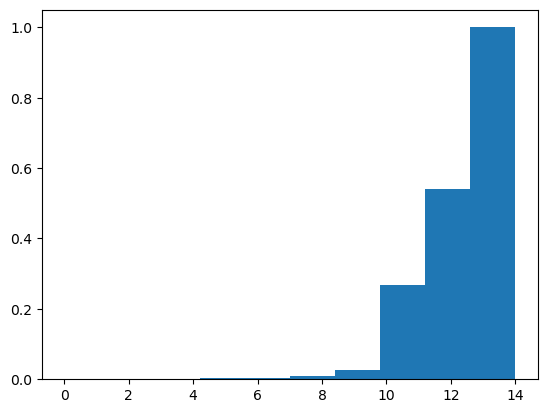

In [79]:
plt.figure()
plt.hist(narr.flat, cumulative=True, density=True)

In [80]:
np.percentile(narr, 0.99)

np.float64(8.0)

In [81]:
template = butler.get('template_coadd', dataId = ref.dataId)


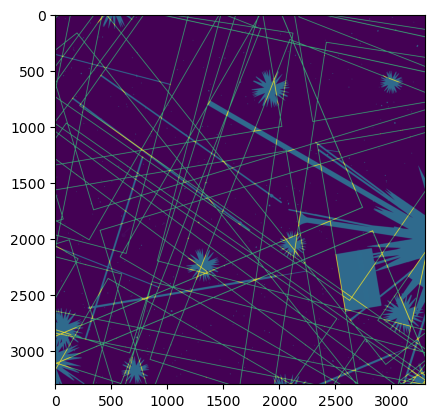

In [87]:
plt.imshow(template.mask.getArray())

In [89]:
table = butler.get('template_depth_table', dataId = ref.dataId)


MissingDatasetTypeError: "Dataset type 'template_depth_table' does not exist."

## estimate fill fator

use a u-band visit that spans the tract with a single visit
tract 4536

In [15]:
refs = butler.query_datasets('template_coadd_n_image', where="band = 'u' AND tract = 4536 AND skymap='lsst_cells_v2'")


In [16]:
ngood = 0
ntot = 0
for ref in refs:
    n_image = butler.get(ref)
    narr = n_image.getArray()
    assert(narr.max() == 1)
    ngood += np.sum(narr)
    ntot += np.size(narr)
print(ngood, ntot, ngood/ntot)

958270589 1089000000 0.8799546271808999


Let's try again and use the NO_DATA masks

In [36]:
nempty = 0
nedge = 0
ntot = 0
for ref in refs:

    
    mask = butler.get('template_coadd.mask', dataId=ref.dataId)
    no_data_bit = mask.getPlaneBitMask("NO_DATA")
    rejected_bit = mask.getPlaneBitMask("REJECTED")
    edge_bit = mask.getPlaneBitMask("SENSOR_EDGE")

    tract_info = skymap[ref.dataId["tract"]]
    patch_info = tract_info[ref.dataId["patch"]]
    inner_bbox = patch_info.getInnerBBox()


    # Pixels where NO_DATA is set AND REJECTED is not set
    nempty += np.sum((mask[inner_bbox].array & no_data_bit != 0) & (mask[inner_bbox].array & rejected_bit == 0))
    nedge += np.sum(mask[inner_bbox].array & edge_bit !=0)
    ntot += np.size(mask[inner_bbox].array)
print(nempty, nedge, ntot,(ntot-nempty)/ntot, (ntot-nempty-nedge)/ntot)

102125200 6004464 900000000 0.8865275555555555 0.8798559288888889


In [30]:
template.array.shape

(3300, 3300)

In [106]:
mask_arr = template.mask.array

In [104]:
no_data_bit

256

In [107]:
# Count pixels where NO_DATA is set AND it's the only bit set
only_no_data = np.sum(mask_arr == no_data_bit)

In [108]:
includes_no_data = np.sum(mask_arr & no_data_bit)

In [109]:
only_no_data

np.int64(0)

In [110]:
includes_no_data

np.int64(254168576)

In [41]:
display1 = lsst.afw.display.Display(backend='firefly',frame=1)


In [42]:
display1.image(template)


## looking at mask fractions stored from DM-54367

In [44]:
butler = dafButler.Butler('dp2_prep', collections='u/mullaney/DM-54367')

In [70]:
refs = butler.query_datasets('deep_coadd_tract_mask_fraction_metricsTable')

In [71]:
len(refs)

6

In [72]:
mask_frac = butler.get(refs[0])

In [73]:
refs[0].dataId

{band: 'g', skymap: 'lsst_cells_v2'}

In [57]:
type(mask_frac)

astropy.table.table.Table

In [60]:
mask_frac

tract,corners,tractMaskFractions_BAD_fraction_ct,tractMaskFractions_BAD_fraction_max,tractMaskFractions_BAD_fraction_mean,tractMaskFractions_BAD_fraction_min,tractMaskFractions_BAD_fraction_valid_ct,tractMaskFractions_BAD_fraction_valid_max,tractMaskFractions_BAD_fraction_valid_mean,tractMaskFractions_BAD_fraction_valid_min,tractMaskFractions_CLIPPED_fraction_ct,tractMaskFractions_CLIPPED_fraction_max,tractMaskFractions_CLIPPED_fraction_mean,tractMaskFractions_CLIPPED_fraction_min,tractMaskFractions_CLIPPED_fraction_valid_ct,tractMaskFractions_CLIPPED_fraction_valid_max,tractMaskFractions_CLIPPED_fraction_valid_mean,tractMaskFractions_CLIPPED_fraction_valid_min,tractMaskFractions_CR_fraction_ct,tractMaskFractions_CR_fraction_max,tractMaskFractions_CR_fraction_mean,tractMaskFractions_CR_fraction_min,tractMaskFractions_CR_fraction_valid_ct,tractMaskFractions_CR_fraction_valid_max,tractMaskFractions_CR_fraction_valid_mean,tractMaskFractions_CR_fraction_valid_min,tractMaskFractions_DETECTED_NEGATIVE_fraction_ct,tractMaskFractions_DETECTED_NEGATIVE_fraction_max,tractMaskFractions_DETECTED_NEGATIVE_fraction_mean,tractMaskFractions_DETECTED_NEGATIVE_fraction_min,tractMaskFractions_DETECTED_NEGATIVE_fraction_valid_ct,tractMaskFractions_DETECTED_NEGATIVE_fraction_valid_max,tractMaskFractions_DETECTED_NEGATIVE_fraction_valid_mean,tractMaskFractions_DETECTED_NEGATIVE_fraction_valid_min,tractMaskFractions_DETECTED_fraction_ct,tractMaskFractions_DETECTED_fraction_max,tractMaskFractions_DETECTED_fraction_mean,tractMaskFractions_DETECTED_fraction_min,tractMaskFractions_DETECTED_fraction_valid_ct,tractMaskFractions_DETECTED_fraction_valid_max,tractMaskFractions_DETECTED_fraction_valid_mean,tractMaskFractions_DETECTED_fraction_valid_min,tractMaskFractions_EDGE_fraction_ct,tractMaskFractions_EDGE_fraction_max,tractMaskFractions_EDGE_fraction_mean,tractMaskFractions_EDGE_fraction_min,tractMaskFractions_EDGE_fraction_valid_ct,tractMaskFractions_EDGE_fraction_valid_max,tractMaskFractions_EDGE_fraction_valid_mean,tractMaskFractions_EDGE_fraction_valid_min,tractMaskFractions_INEXACT_PSF_fraction_ct,tractMaskFractions_INEXACT_PSF_fraction_max,tractMaskFractions_INEXACT_PSF_fraction_mean,tractMaskFractions_INEXACT_PSF_fraction_min,tractMaskFractions_INEXACT_PSF_fraction_valid_ct,tractMaskFractions_INEXACT_PSF_fraction_valid_max,tractMaskFractions_INEXACT_PSF_fraction_valid_mean,tractMaskFractions_INEXACT_PSF_fraction_valid_min,tractMaskFractions_INTRP_fraction_ct,tractMaskFractions_INTRP_fraction_max,tractMaskFractions_INTRP_fraction_mean,tractMaskFractions_INTRP_fraction_min,tractMaskFractions_INTRP_fraction_valid_ct,tractMaskFractions_INTRP_fraction_valid_max,tractMaskFractions_INTRP_fraction_valid_mean,tractMaskFractions_INTRP_fraction_valid_min,tractMaskFractions_NOT_DEBLENDED_fraction_ct,tractMaskFractions_NOT_DEBLENDED_fraction_max,tractMaskFractions_NOT_DEBLENDED_fraction_mean,tractMaskFractions_NOT_DEBLENDED_fraction_min,tractMaskFractions_NOT_DEBLENDED_fraction_valid_ct,tractMaskFractions_NOT_DEBLENDED_fraction_valid_max,tractMaskFractions_NOT_DEBLENDED_fraction_valid_mean,tractMaskFractions_NOT_DEBLENDED_fraction_valid_min,tractMaskFractions_NO_DATA_fraction_ct,tractMaskFractions_NO_DATA_fraction_max,tractMaskFractions_NO_DATA_fraction_mean,tractMaskFractions_NO_DATA_fraction_min,tractMaskFractions_PARTLY_VIGNETTED_fraction_ct,tractMaskFractions_PARTLY_VIGNETTED_fraction_max,tractMaskFractions_PARTLY_VIGNETTED_fraction_mean,tractMaskFractions_PARTLY_VIGNETTED_fraction_min,tractMaskFractions_PARTLY_VIGNETTED_fraction_valid_ct,tractMaskFractions_PARTLY_VIGNETTED_fraction_valid_max,tractMaskFractions_PARTLY_VIGNETTED_fraction_valid_mean,tractMaskFractions_PARTLY_VIGNETTED_fraction_valid_min,tractMaskFractions_REJECTED_fraction_ct,tractMaskFractions_REJECTED_fraction_max,tractMaskFractions_REJECTED_fraction_mean,tractMaskFractions_REJECTED_fraction_min,tractMaskFractions_REJECTED_fraction_valid_ct,tractMaskFractions_REJECTED_fraction_valid_max,t

In [61]:
mask_frac.columns

<TableColumns names=('tract','corners','tractMaskFractions_BAD_fraction_ct','tractMaskFractions_BAD_fraction_max','tractMaskFractions_BAD_fraction_mean','tractMaskFractions_BAD_fraction_min','tractMaskFractions_BAD_fraction_valid_ct','tractMaskFractions_BAD_fraction_valid_max','tractMaskFractions_BAD_fraction_valid_mean','tractMaskFractions_BAD_fraction_valid_min','tractMaskFractions_CLIPPED_fraction_ct','tractMaskFractions_CLIPPED_fraction_max','tractMaskFractions_CLIPPED_fraction_mean','tractMaskFractions_CLIPPED_fraction_min','tractMaskFractions_CLIPPED_fraction_valid_ct','tractMaskFractions_CLIPPED_fraction_valid_max','tractMaskFractions_CLIPPED_fraction_valid_mean','tractMaskFractions_CLIPPED_fraction_valid_min','tractMaskFractions_CR_fraction_ct','tractMaskFractions_CR_fraction_max','tractMaskFractions_CR_fraction_mean','tractMaskFractions_CR_fraction_min','tractMaskFractions_CR_fraction_valid_ct','tractMaskFractions_CR_fraction_valid_max','tractMaskFractions_CR_fraction_valid_me

(array([372., 796., 351., 132.,  35.,  31.,  25.,  22.,  23.,  12.]),
 array([0.        , 0.09918922, 0.19837845, 0.29756767, 0.3967569 ,
        0.49594612, 0.59513535, 0.69432457, 0.7935138 , 0.89270302,
        0.99189225]),
 <BarContainer object of 10 artists>)

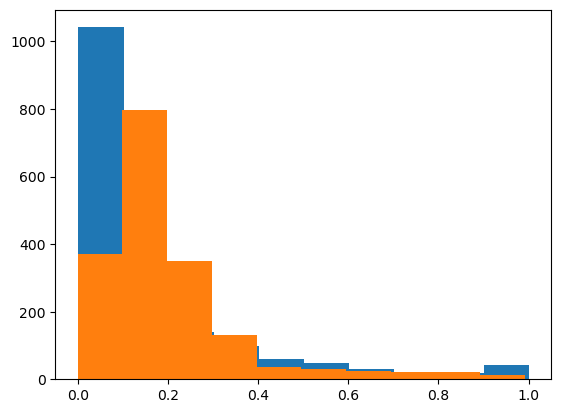

In [74]:
plt.figure()
plt.hist(mask_frac['tractMaskFractions_NO_DATA_fraction_mean'], label='NO_DATA')
plt.hist(mask_frac['tractMaskFractions_REJECTED_fraction_mean'], label='REJECTED')

Text(0, 0.5, 'REJECTED fraction')

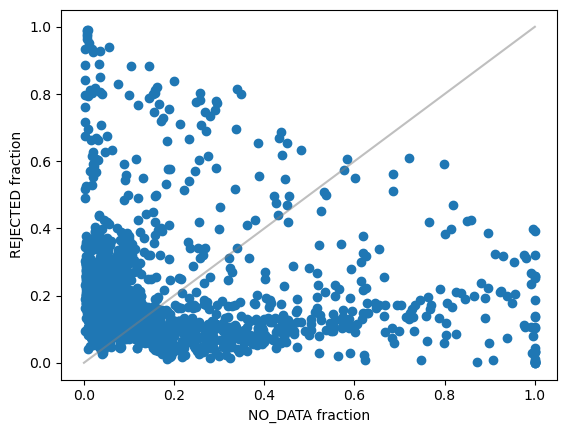

In [77]:
plt.figure()
plt.scatter(mask_frac['tractMaskFractions_NO_DATA_fraction_mean'],mask_frac['tractMaskFractions_REJECTED_fraction_mean'])
plt.plot([0,1],[0,1], color='gray', alpha=0.5)
plt.xlabel('NO_DATA fraction')
plt.ylabel('REJECTED fraction')


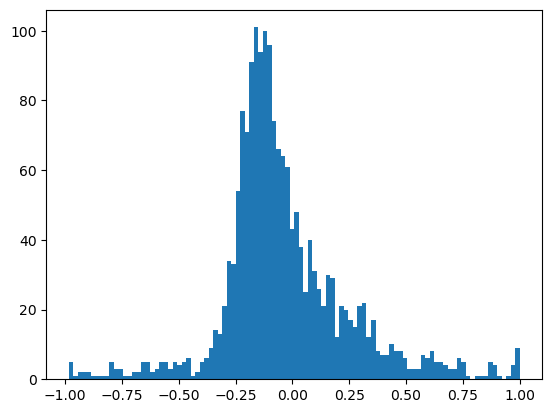

In [80]:
plt.figure()
_ = plt.hist(mask_frac['tractMaskFractions_NO_DATA_fraction_mean']- mask_frac['tractMaskFractions_REJECTED_fraction_mean'], bins=100)

In [89]:
diff = mask_frac['tractMaskFractions_NO_DATA_fraction_mean']- mask_frac['tractMaskFractions_REJECTED_fraction_mean']
wgaps = (diff > 0.1) & (diff < 0.15)

In [99]:
mask_frac[wgaps]['tractMaskFractions_NO_DATA_fraction_mean']

0.2335560702971838
0.2776797111207589
0.2402996940146987
0.23867575639144745
0.22619234178844116
0.22733150949571207
0.1590886213503389
0.2003820266781747
0.17098258457490922
0.1728771197346221
0.21966377878727933


In [90]:
mask_frac[wgaps]['tract']

2209
4149
4356
4761
5002
5407
5442
5668
5853
5888
5894


(array([  91.,   47.,   43.,   32.,   29.,   39.,   37.,   46.,   52.,
        1383.]),
 array([  1. ,  10.9,  20.8,  30.7,  40.6,  50.5,  60.4,  70.3,  80.2,
         90.1, 100. ]),
 <BarContainer object of 10 artists>)

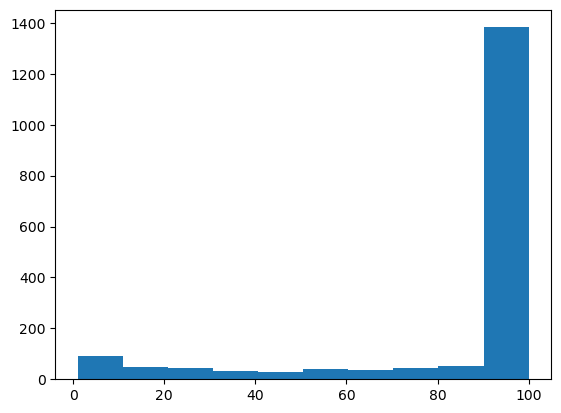

In [62]:
plt.hist(mask_frac['tractMaskFractions_BAD_fraction_ct'])